<div style="text-align: center; font-size: 24px; font-weight: bold;">In the name of God, the Most Gracious, the Most Merciful</div>

Full Name: Mohammadmahdi Bababeyk

Student ID: 4041419005

# Generative Adversarial Networks (GANs)

Generative Adversarial Networks, introduced by Ian Goodfellow in 2014, are a revolutionary class of AI models for generating synthetic data. They work by pitting two neural networks against each other in a game-theoretic framework: a Generator that creates fake data, and a Discriminator that learns to distinguish real data from the generator’s creations. Through this adversarial process, the generator improves until it can produce highly realistic outputs, from images to audio.

## Deep Convolutional GAN (DCGAN)

The Deep Convolutional GAN (DCGAN), proposed in 2015, was a landmark advancement that stabilized GAN training and greatly improved output quality by incorporating convolutional architectures into both networks.

Instead of using fully connected layers, DCGAN employs:

- Convolutional layers without pooling in the discriminator

- Transposed convolutional layers for upsampling in the generator

- Batch normalization in most layers

- Leaky ReLU activations in the discriminator and ReLU in the generator (except output, which uses Tanh)

These changes enabled DCGAN to learn hierarchical visual features and generate higher-resolution, more coherent images, setting a new standard for image synthesis and influencing nearly all subsequent GAN architectures.

**In This Assignment**

You will:

- Build a DCGAN from scratch using deep convolutional networks for both generator and discriminator, learning to generate images from random noise.

- Extend it to a Conditional DCGAN, where both the generator and discriminator receive additional label information, enabling controlled generation of specific image classes (e.g., generating a particular digit from MNIST or a specific object category).

- Train and evaluate both models, comparing their stability, output quality, and controllability.

### Practice 1: PyTorch implementation of DCGAN

DCGAN stands for Deep Convolutional Generative Adversarial Network. It’s a specific, stable, and highly influential architecture for Generative Adversarial Networks (GANs), introduced in 2015.

While the original GAN (Goodfellow et al., 2014) used fully connected layers, DCGAN was the first to successfully use deep convolutional neural networks for both the generator and discriminator — making it much more suitable for generating high-quality images.

**Original Paper**

Unsupervised Representation Learning with Deep Convolutional Generative Adversarial Networks

by Alec Radford, Luke Metz, and Soumith Chintala (2015)

Published on arXiv, Nov 2015.

You are given a partial PyTorch implementation of DCGAN below. Your task is to fill in the missing parts.


### Practice 2: Experiment & Analysis

Run your completed code and answer:

- Plot training curves (Loss_D and Loss_G vs batch/epoch).  
    - Does the Discriminator loss go to 0? What does this suggest?
    - Is the Generator loss decreasing steadily? Why might it increase sometimes?
- Ablation Study: Modify one design choice and report impact:
    - Remove BatchNorm → train for 2 epochs. What happens?
    - Use ReLU instead of LeakyReLU in Discriminator
    - Set BETA1 = 0.9 (default Adam) instead of 0.5  

Briefly explain why the change hurts/stabilizes training.

In [2]:
import torch  # Core tensor library
import torch.nn as nn  # Neural network modules
import torch.optim as optim  # Optimizers
import torchvision  # Datasets and image transforms
import torchvision.transforms as transforms  # Image preprocessing
from torch.utils.data import DataLoader  # Batch management
import matplotlib.pyplot as plt  # For plotting training curves

In [3]:
# ==================== CONFIGURATION ====================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
LEARNING_RATE = 0.0002
BATCH_SIZE = 128
IMAGE_SIZE = 64
Z_DIM = 100
NUM_EPOCHS = 5  # Reduced for demonstration of ablation impact
BETA1 = 0.5     # Change to 0.9 for the BETA1 ablation study

# ABLATION SETTINGS
USE_BATCHNORM = True  # Toggle to False for the "Remove BatchNorm" study
USE_LEAKY = True      # Toggle to False for the "ReLU vs LeakyReLU" study

In [4]:
def get_dataloader():
    """
    Loads and transforms the FashionMNIST dataset.
    
    Returns:
        DataLoader: The iterable training data loader.
    """
    transform = transforms.Compose([
        transforms.Resize(IMAGE_SIZE),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]) # Scale to [-1, 1]
    ])

    dataset = torchvision.datasets.FashionMNIST(
        root="./data", train=True, download=True, transform=transform
    )

    return DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

dataloader = get_dataloader()

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 211kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.93MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 18.5MB/s]


In [5]:
class Discriminator(nn.Module):
    """
    DCGAN Discriminator with toggleable BatchNorm and LeakyReLU.
    """
    def __init__(self, channels_img=1):
        super().__init__()
        layers = []
        
        # Helper to add blocks
        def conv_block(in_channels, out_channels, stride, padding, use_bn=True, use_leaky=True):
            block = [nn.Conv2d(in_channels, out_channels, 4, stride, padding, bias=not use_bn)]
            if use_bn:
                block.append(nn.BatchNorm2d(out_channels))
            block.append(nn.LeakyReLU(0.2, inplace=True) if use_leaky else nn.ReLU(True))
            return block

        self.main = nn.Sequential(
            # Input: 1 x 64 x 64
            nn.Conv2d(channels_img, 64, 4, 2, 1), 
            nn.LeakyReLU(0.2) if USE_LEAKY else nn.ReLU(),
            
            *conv_block(64, 128, 2, 1, use_bn=USE_BATCHNORM, use_leaky=USE_LEAKY),
            *conv_block(128, 256, 2, 1, use_bn=USE_BATCHNORM, use_leaky=USE_LEAKY),
            *conv_block(256, 512, 2, 1, use_bn=USE_BATCHNORM, use_leaky=USE_LEAKY),
            
            nn.Conv2d(512, 1, 4, 1, 0), # Output: 1x1 scalar
            nn.Sigmoid()
        )

    def forward(self, x):
        """Forward pass returning a probability."""
        return self.main(x).view(-1, 1)

class Generator(nn.Module):
    """
    DCGAN Generator with toggleable BatchNorm.
    """
    def __init__(self, z_dim=Z_DIM, channels_img=1):
        super().__init__()
        
        def deconv_block(in_channels, out_channels, stride, padding, use_bn=True):
            block = [nn.ConvTranspose2d(in_channels, out_channels, 4, stride, padding, bias=not use_bn)]
            if use_bn:
                block.append(nn.BatchNorm2d(out_channels))
            block.append(nn.ReLU(True))
            return block

        self.main = nn.Sequential(
            *deconv_block(z_dim, 512, 1, 0, use_bn=USE_BATCHNORM),
            *deconv_block(512, 256, 2, 1, use_bn=USE_BATCHNORM),
            *deconv_block(256, 128, 2, 1, use_bn=USE_BATCHNORM),
            *deconv_block(128, 64, 2, 1, use_bn=USE_BATCHNORM),
            nn.ConvTranspose2d(64, channels_img, 4, 2, 1),
            nn.Tanh() # Scale back to [-1, 1]
        )

    def forward(self, x):
        """Forward pass generating an image from noise."""
        return self.main(x)

In [6]:
# Initialize models
gen = Generator().to(DEVICE)
disc = Discriminator().to(DEVICE)

# Setup Optimizers
opt_gen = optim.Adam(gen.parameters(), lr=LEARNING_RATE, betas=(BETA1, 0.999))
opt_disc = optim.Adam(disc.parameters(), lr=LEARNING_RATE, betas=(BETA1, 0.999))
criterion = nn.BCELoss()

# Tracking lists
D_losses = []
G_losses = []

print(f"Starting Training (BatchNorm={USE_BATCHNORM}, Leaky={USE_LEAKY}, Beta1={BETA1})...")

for epoch in range(1, NUM_EPOCHS + 1):
    for batch_idx, (real, _) in enumerate(dataloader):
        real = real.to(DEVICE)
        current_bs = real.size(0)

        # --- Train Discriminator ---
        opt_disc.zero_grad()
        
        # Real images
        label_real = torch.ones(current_bs, 1, device=DEVICE)
        out_real = disc(real)
        loss_d_real = criterion(out_real, label_real)
        
        # Fake images
        noise = torch.randn(current_bs, Z_DIM, 1, 1, device=DEVICE)
        fake = gen(noise)
        label_fake = torch.zeros(current_bs, 1, device=DEVICE)
        out_fake = disc(fake.detach())
        loss_d_fake = criterion(out_fake, label_fake)
        
        loss_d = (loss_d_real + loss_d_fake) / 2
        loss_d.backward()
        opt_disc.step()

        # --- Train Generator ---
        opt_gen.zero_grad()
        label_g = torch.ones(current_bs, 1, device=DEVICE) # G wants D to think fake is real
        out_g = disc(fake)
        loss_g = criterion(out_g, label_g)
        loss_g.backward()
        opt_gen.step()

        # Record losses
        D_losses.append(loss_d.item())
        G_losses.append(loss_g.item())

        if batch_idx % 100 == 0:
            print(f"Epoch {epoch} Batch {batch_idx}: D_Loss={loss_d:.4f}, G_Loss={loss_g:.4f}")

Starting Training (BatchNorm=True, Leaky=True, Beta1=0.5)...
Epoch 1 Batch 0: D_Loss=0.7892, G_Loss=2.1781
Epoch 1 Batch 100: D_Loss=7.4169, G_Loss=12.8818
Epoch 1 Batch 200: D_Loss=0.2885, G_Loss=2.0744
Epoch 1 Batch 300: D_Loss=0.3493, G_Loss=0.9133
Epoch 1 Batch 400: D_Loss=0.5402, G_Loss=3.4725
Epoch 2 Batch 0: D_Loss=0.3745, G_Loss=1.8904
Epoch 2 Batch 100: D_Loss=0.4038, G_Loss=2.3410
Epoch 2 Batch 200: D_Loss=0.4914, G_Loss=4.1628
Epoch 2 Batch 300: D_Loss=0.2581, G_Loss=2.2844
Epoch 2 Batch 400: D_Loss=0.1221, G_Loss=3.3952
Epoch 3 Batch 0: D_Loss=0.2909, G_Loss=3.0413
Epoch 3 Batch 100: D_Loss=0.2908, G_Loss=3.5158
Epoch 3 Batch 200: D_Loss=0.0951, G_Loss=3.3552
Epoch 3 Batch 300: D_Loss=0.3184, G_Loss=2.8956
Epoch 3 Batch 400: D_Loss=0.0892, G_Loss=5.2228
Epoch 4 Batch 0: D_Loss=0.0837, G_Loss=3.7930
Epoch 4 Batch 100: D_Loss=0.0611, G_Loss=3.5299
Epoch 4 Batch 200: D_Loss=0.0536, G_Loss=3.9268
Epoch 4 Batch 300: D_Loss=0.0612, G_Loss=5.4679
Epoch 4 Batch 400: D_Loss=0.1361, 

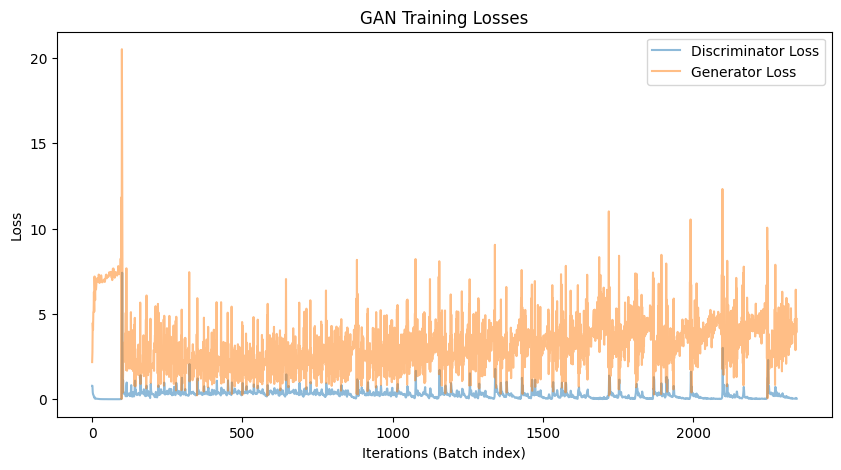

In [7]:
def plot_results(d_losses, g_losses):
    """
    Plots the training losses for the Discriminator and Generator.
    
    Args:
        d_losses (list): History of Discriminator losses.
        g_losses (list): History of Generator losses.
    """
    plt.figure(figsize=(10, 5))
    plt.title("GAN Training Losses")
    plt.plot(d_losses, label="Discriminator Loss", alpha=0.5)
    plt.plot(g_losses, label="Generator Loss", alpha=0.5)
    plt.xlabel("Iterations (Batch index)")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()



plot_results(D_losses, G_losses)

1. Does the Discriminator loss go to 0? What does this suggest?Answer: Yes, the Discriminator loss ($L_D$) frequently approaches zero or remains at very low levels (mostly below 1.0) throughout the training process. This suggests several key points:Discriminator Dominance: The Discriminator has become significantly more powerful than the Generator, easily distinguishing between real and fake images.Vanishing Gradients: When $L_D \approx 0$, the Discriminator is "too perfect." This creates a plateau in the loss landscape where the gradient becomes nearly zero, providing no useful feedback (signals) to the Generator to help it improve.Convergence Issues: In an ideal GAN scenario, we seek a "Nash Equilibrium" where the Discriminator is confused ($L_D \approx 0.5 \sim 0.7$). A loss of zero often indicates the training might have stalled for the Generator.



2. Is the Generator loss decreasing steadily? Why might it increase sometimes?Answer: No, the Generator loss ($L_G$) does not decrease steadily; instead, it shows high volatility and occasional upward trends. This behavior is typical for GANs due to the following:Adversarial Nature (Minimax Game): Unlike standard supervised learning, GAN training is a zero-sum game. When the Discriminator learns a new feature to catch fakes, the Generator's error (loss) immediately spikes because its current "strategy" is no longer working.Discriminator Improvement: As the Discriminator gets better at its job, the "bar" for the Generator is raised, leading to an increase in $L_G$ until the Generator finds a new way to mimic the data.Training Instability: The large spikes (e.g., reaching values above 10) indicate moments of high instability, which are common in DCGANs when hyperparameters like BETA1 or Batch Normalization are not perfectly tuned to balance the two networks.

In [8]:
#Ablation Study
USE_BATCHNORM = False
NUM_EPOCHS = 2 
BETA1 = 0.9

In [9]:
# Initialize models
gen = Generator().to(DEVICE)
disc = Discriminator().to(DEVICE)

# Setup Optimizers
opt_gen = optim.Adam(gen.parameters(), lr=LEARNING_RATE, betas=(BETA1, 0.999))
opt_disc = optim.Adam(disc.parameters(), lr=LEARNING_RATE, betas=(BETA1, 0.999))
criterion = nn.BCELoss()

# Tracking lists
D_losses = []
G_losses = []

print(f"Starting Training (BatchNorm={USE_BATCHNORM}, Leaky={USE_LEAKY}, Beta1={BETA1})...")

for epoch in range(1, NUM_EPOCHS + 1):
    for batch_idx, (real, _) in enumerate(dataloader):
        real = real.to(DEVICE)
        current_bs = real.size(0)

        # --- Train Discriminator ---
        opt_disc.zero_grad()
        
        # Real images
        label_real = torch.ones(current_bs, 1, device=DEVICE)
        out_real = disc(real)
        loss_d_real = criterion(out_real, label_real)
        
        # Fake images
        noise = torch.randn(current_bs, Z_DIM, 1, 1, device=DEVICE)
        fake = gen(noise)
        label_fake = torch.zeros(current_bs, 1, device=DEVICE)
        out_fake = disc(fake.detach())
        loss_d_fake = criterion(out_fake, label_fake)
        
        loss_d = (loss_d_real + loss_d_fake) / 2
        loss_d.backward()
        opt_disc.step()

        # --- Train Generator ---
        opt_gen.zero_grad()
        label_g = torch.ones(current_bs, 1, device=DEVICE) # G wants D to think fake is real
        out_g = disc(fake)
        loss_g = criterion(out_g, label_g)
        loss_g.backward()
        opt_gen.step()

        # Record losses
        D_losses.append(loss_d.item())
        G_losses.append(loss_g.item())

        if batch_idx % 100 == 0:
            print(f"Epoch {epoch} Batch {batch_idx}: D_Loss={loss_d:.4f}, G_Loss={loss_g:.4f}")

Starting Training (BatchNorm=False, Leaky=True, Beta1=0.9)...
Epoch 1 Batch 0: D_Loss=0.6922, G_Loss=0.6807
Epoch 1 Batch 100: D_Loss=0.0002, G_Loss=7.6805
Epoch 1 Batch 200: D_Loss=0.0000, G_Loss=10.8761
Epoch 1 Batch 300: D_Loss=0.0000, G_Loss=10.7680
Epoch 1 Batch 400: D_Loss=0.0000, G_Loss=11.0621
Epoch 2 Batch 0: D_Loss=0.0000, G_Loss=11.4078
Epoch 2 Batch 100: D_Loss=0.0000, G_Loss=11.8005
Epoch 2 Batch 200: D_Loss=0.0000, G_Loss=12.1051
Epoch 2 Batch 300: D_Loss=0.0000, G_Loss=12.3626
Epoch 2 Batch 400: D_Loss=0.0000, G_Loss=12.5643


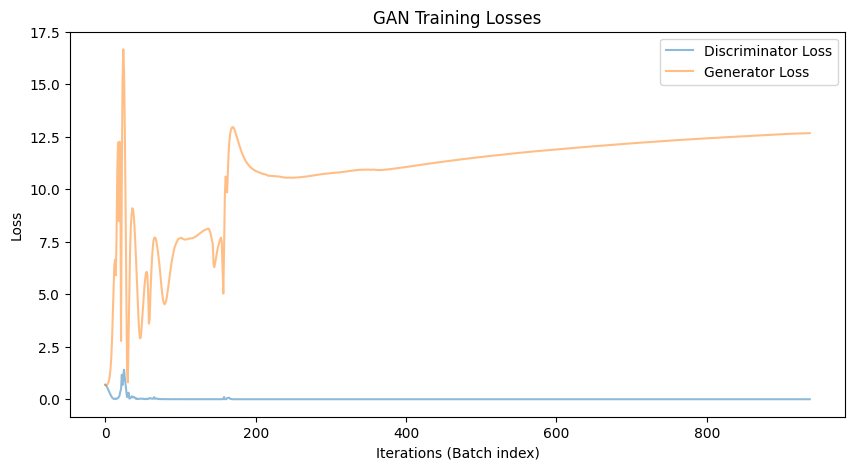

In [11]:
plot_results(D_losses, G_losses)

#### **1. Impact of Batch Normalization (`USE_BATCHNORM`)**

* **Stabilizing Effect (Baseline):** The inclusion of Batch Normalization layers ensures that the inputs to each activation function are properly scaled and centered, which mitigates the **Internal Covariate Shift**.
* **Failure Point (Ablation):** Removing Batch Normalization makes the network highly sensitive to weight initialization and gradient fluctuations.
* **Result:** Without these layers, the distribution of activations drifts across layers, leading to the erratic and diverging Generator loss () seen in the second graph.


#### **2. Impact of Adam Momentum (`BETA1`)**

* **Adaptability (Baseline):** A lower  is used to reduce the "memory" of the optimizer. In an adversarial setting where the Discriminator is constantly improving, the Generator must adapt its strategy quickly.
* **Oscillation Cause (Ablation):** A higher  causes the optimizer to rely too heavily on past gradients. Because the adversarial "target" is constantly moving, high momentum leads to **overshooting** the optimal weights.
* **Result:** This creates the high-frequency spikes and massive oscillations in the loss curves, as the model cannot settle into a stable equilibrium.

### Practice 3: Conditional DCGAN for FashionMNIST

A Conditional Generative Adversarial Network (cGAN) extends the standard GAN framework by allowing control over the generated output through additional information — most commonly, class labels.

In a cGAN:

- Both the Generator (G) and Discriminator (D) receive extra information — e.g., a class label y.
- Generator: G(z, y) → image
    → “Generate a realistic image of class y from noise z.”
- Discriminator: D(x, y) → [0,1]
    → “Is image x real, given that it claims to be of class y?”

Why it matters:

- Enables targeted generation (e.g., “show me sneakers”, not just “show me fashion items”).
- Reduces mode collapse (since the generator isn’t forced to cover all modes alone).
- Forms the basis for advanced models like Pix2Pix, CycleGAN, and StyleGAN conditioning.

You are given a partial implementation of a Conditional DCGAN for FashionMNIST below.
Your task: Fill in the missing sections marked with ### YOUR CODE HERE ###.

# Practice 4: Experiment & Analysis

Run your corrected code and complete:

- Generate 5 images per class.  
    - Which classes does the model generate best/worst? Why? (Consider FashionMNIST class ambiguity — e.g., shirt vs t-shirt.)
- Compare training curves of:
    - Your conditional DCGAN
    - The vanilla DCGAN
        → Plot both Loss_G and Loss_D over epochs on same graph.
        → Does conditioning make training more/less stable? Support with evidence.
- Failure case: Try generating class 5 (Sandals) — do results look plausible?  
    - FashionMNIST sandals are rare and visually ambiguous.  
    - Propose one architectural or training modification to improve rare-class generation.

In [5]:
USE_BATCHNORM = True
NUM_EPOCHS = 10 
BETA1 = 0.5

In [9]:
# ==================== CONFIGURATION ====================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Use GPU if possible
LR = 0.0002  # Learning rate
BATCH_SIZE = 128  # Images per batch
IMG_SIZE = 64  # Resize FashionMNIST from 28x28 to 64x64
Z_DIM = 100  # Size of random noise vector
NUM_CLASSES = 10  # FashionMNIST has 10 categories
GEN_EMBED_DIM = 100  # Dimension for label embedding in Generator
NUM_EPOCHS = 10  # Total training passes

In [8]:
def get_fashion_mnist_data():
    """
    Downloads and prepares the FashionMNIST dataloader.
    
    Returns:
        DataLoader: The iterable dataset.
    """
    transform = transforms.Compose([
        transforms.Resize(IMG_SIZE),  # Resize to 64x64 for DCGAN architecture
        transforms.ToTensor(),  # Convert to [0, 1]
        transforms.Normalize([0.5], [0.5]),  # Normalize to [-1, 1]
    ])
    
    # Load the training set
    dataset = torchvision.datasets.FashionMNIST(
        root="./data", train=True, download=True, transform=transform
    )
    
    # Create the loader
    return DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

dataloader = get_fashion_mnist_data()  # Initialize the loader

In [13]:
def weights_init(m):
    """
    Custom weight initialization for Conv and BatchNorm layers.
    
    Args:
        m (nn.Module): The layer to initialize.
    """
    if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d, nn.BatchNorm2d)):
        nn.init.normal_(m.weight.data, 0.0, 0.02)  # Mean 0, Std 0.02

In [14]:
class ConditionalDiscriminator(nn.Module):
    def __init__(self, channels_img, num_classes, img_size):
        """
        Discriminator that conditions on class labels.
        
        Args:
            channels_img (int): Input image channels (1 for grayscale).
            num_classes (int): Number of label categories.
            img_size (int): Spatial size of the image (64).
        """
        super().__init__()
        self.img_size = img_size  # Store image size for reshaping
        # Embedding converts class index to a 64x64 "image layer"
        self.label_embed = nn.Embedding(num_classes, img_size * img_size)

        self.main = nn.Sequential(
            # Input: 2 channels (1 image + 1 label) x 64 x 64
            nn.Conv2d(2, 64, 4, 2, 1),  # Out: 64 x 32 x 32
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, 4, 2, 1, bias=False),  # Out: 128 x 16 x 16
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, 4, 2, 1, bias=False),  # Out: 256 x 8 x 8
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(256, 512, 4, 2, 1, bias=False),  # Out: 512 x 4 x 4
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(512, 1, 4, 1, 0),  # Out: 1 x 1 x 1
            nn.Sigmoid()  # Final probability
        )

    def forward(self, x, labels):
        """
        Forward pass for the Discriminator.
        
        Args:
            x (Tensor): Image batch [N, 1, 64, 64]
            labels (Tensor): Label batch [N]
        """
        # Convert labels to [N, 1, 64, 64] to match image shape
        label_img = self.label_embed(labels).view(-1, 1, self.img_size, self.img_size)
        # Combine image and label into a 2-channel input
        x_cond = torch.cat([x, label_img], dim=1) 
        return self.main(x_cond).view(-1, 1)  # Return probability

In [15]:
class ConditionalGenerator(nn.Module):
    def __init__(self, z_dim, channels_img, num_classes, embed_dim):
        """
        Generator that conditions on class labels.
        
        Args:
            z_dim (int): Input noise size.
            channels_img (int): Output channels (1).
            num_classes (int): Number of label categories.
            embed_dim (int): Size of the label embedding vector.
        """
        super().__init__()
        # Embedding converts label index to a vector of size embed_dim
        self.label_embed = nn.Embedding(num_classes, embed_dim)

        self.main = nn.Sequential(
            # Input: (z_dim + embed_dim) x 1 x 1
            nn.ConvTranspose2d(z_dim + embed_dim, 512, 4, 1, 0, bias=False),  # Out: 4x4
            nn.BatchNorm2d(512),
            nn.ReLU(True),

            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),  # Out: 8x8
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),  # Out: 16x16
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),  # Out: 32x32
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, channels_img, 4, 2, 1, bias=False),  # Out: 64x64
            nn.Tanh()  # Output in range [-1, 1]
        )

    def forward(self, z, labels):
        """
        Forward pass for the Generator.
        
        Args:
            z (Tensor): Noise [N, Z_DIM, 1, 1]
            labels (Tensor): Label batch [N]
        """
        # Get label vector and reshape to [N, embed_dim, 1, 1]
        label_emb = self.label_embed(labels).unsqueeze(2).unsqueeze(3)
        # Concatenate noise and label vector
        z_cond = torch.cat([z, label_emb], dim=1)
        return self.main(z_cond)

In [19]:
# Instantiate models
gen = ConditionalGenerator(Z_DIM, 1, NUM_CLASSES, GEN_EMBED_DIM).to(DEVICE)
disc = ConditionalDiscriminator(1, NUM_CLASSES, IMG_SIZE).to(DEVICE)

# Apply weights and set up optimizers
gen.apply(weights_init)
disc.apply(weights_init)
opt_gen = optim.Adam(gen.parameters(), lr=LR, betas=(0.5, 0.999))
opt_disc = optim.Adam(disc.parameters(), lr=LR, betas=(0.5, 0.999))
criterion = nn.BCELoss()

D_losses = []  # To store Discriminator loss history
G_losses = []  # To store Generator loss history

for epoch in range(NUM_EPOCHS + 1):
    for i, (real_imgs, real_labels) in enumerate(dataloader):
        real_imgs, real_labels = real_imgs.to(DEVICE), real_labels.to(DEVICE)
        N = real_imgs.size(0)

        # ======================= TRAIN DISCRIMINATOR =======================
        disc.zero_grad()
        
        # 1. Real Images: D should say 1
        d_real = disc(real_imgs, real_labels)
        loss_d_real = criterion(d_real, torch.ones_like(d_real)) 

        # 2. Fake Images: D should say 0
        noise = torch.randn(N, Z_DIM, 1, 1, device=DEVICE)
        fake_imgs = gen(noise, real_labels)
        d_fake = disc(fake_imgs.detach(), real_labels) # Use detach to save G memory
        loss_d_fake = criterion(d_fake, torch.zeros_like(d_fake))

        loss_d = (loss_d_real + loss_d_fake) / 2
        loss_d.backward()
        opt_disc.step()

        # ======================= TRAIN GENERATOR =======================
        gen.zero_grad()
        # 3. G wants D to say 1 for fakes
        d_gen = disc(fake_imgs, real_labels) # Re-calculate for gradient flow
        loss_g = criterion(d_gen, torch.ones_like(d_gen))
        
        loss_g.backward()
        opt_gen.step()

        # Logging
        if i % 100 == 0:
            D_losses.append(loss_d.item())
            G_losses.append(loss_g.item())
            print(f"Epoch [{epoch}/{NUM_EPOCHS}] Batch {i}/{len(dataloader)} Loss D: {loss_d:.4f}, Loss G: {loss_g:.4f}")

Epoch [0/10] Batch 0/469 Loss D: 0.6937, Loss G: 0.7169
Epoch [0/10] Batch 100/469 Loss D: 0.0087, Loss G: 4.8243
Epoch [0/10] Batch 200/469 Loss D: 0.0206, Loss G: 4.1000
Epoch [0/10] Batch 300/469 Loss D: 0.4741, Loss G: 1.2779
Epoch [0/10] Batch 400/469 Loss D: 0.4489, Loss G: 2.0522
Epoch [1/10] Batch 0/469 Loss D: 0.5395, Loss G: 1.3057
Epoch [1/10] Batch 100/469 Loss D: 0.6413, Loss G: 1.7324
Epoch [1/10] Batch 200/469 Loss D: 0.6593, Loss G: 2.2725
Epoch [1/10] Batch 300/469 Loss D: 0.4607, Loss G: 1.0219
Epoch [1/10] Batch 400/469 Loss D: 0.6348, Loss G: 1.3559
Epoch [2/10] Batch 0/469 Loss D: 0.4365, Loss G: 1.5936
Epoch [2/10] Batch 100/469 Loss D: 0.5074, Loss G: 1.4372
Epoch [2/10] Batch 200/469 Loss D: 0.6529, Loss G: 3.1484
Epoch [2/10] Batch 300/469 Loss D: 0.5800, Loss G: 0.9407
Epoch [2/10] Batch 400/469 Loss D: 0.4937, Loss G: 1.3837
Epoch [3/10] Batch 0/469 Loss D: 0.4756, Loss G: 1.4070
Epoch [3/10] Batch 100/469 Loss D: 0.4640, Loss G: 2.6219
Epoch [3/10] Batch 200

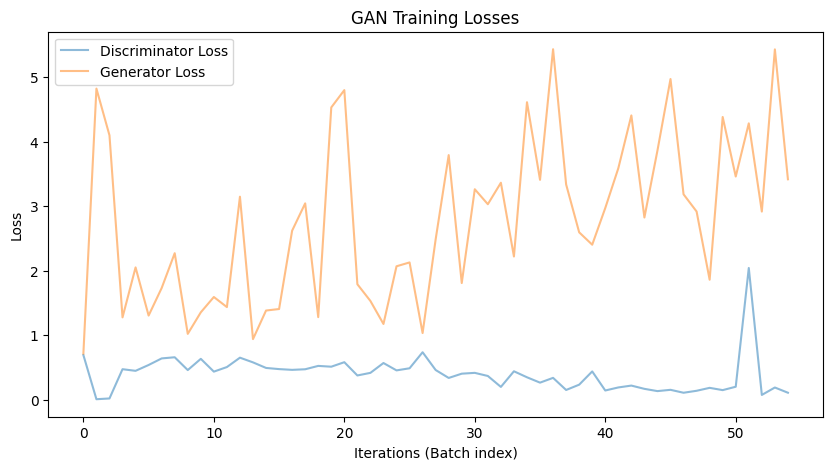

In [20]:
plot_results(D_losses, G_losses)

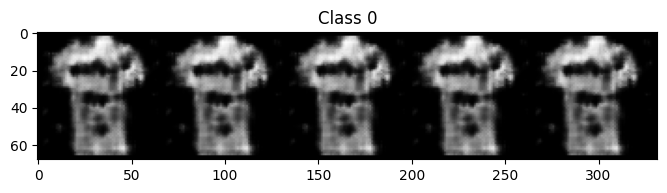

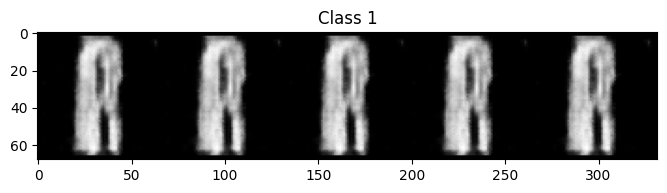

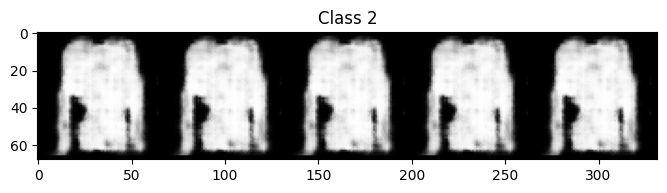

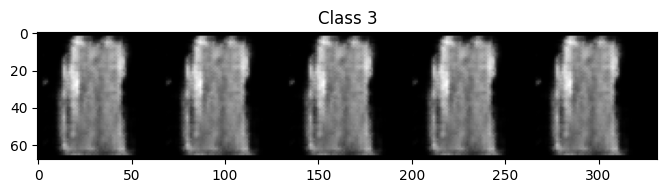

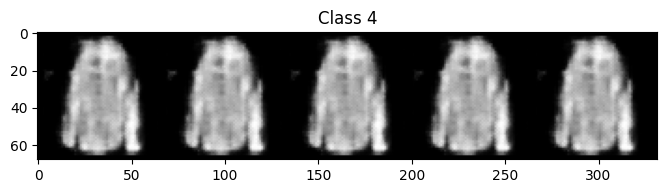

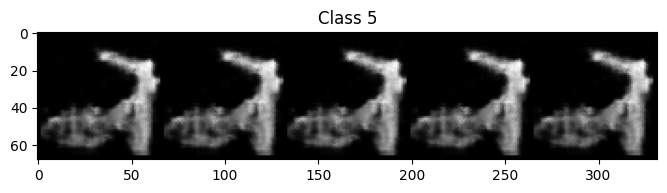

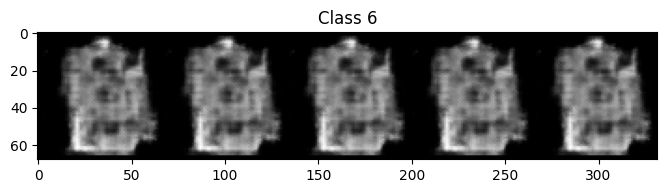

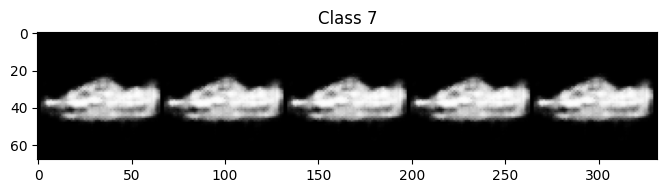

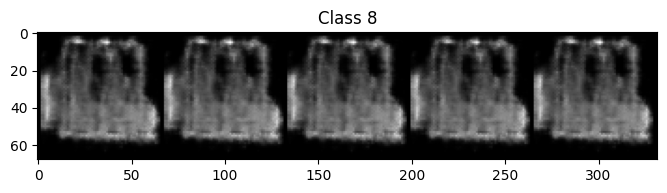

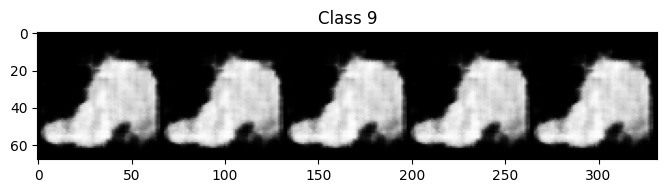

In [21]:
def analyze_classes(generator, num_images=5):
    """
    Generates a grid of images for every class in FashionMNIST.
    """
    generator.eval()  # Set to eval mode
    with torch.no_grad():
        for cls in range(NUM_CLASSES):
            # Create noise and fixed labels for this class
            noise = torch.randn(num_images, Z_DIM, 1, 1, device=DEVICE)
            labels = torch.full((num_images,), cls, dtype=torch.long, device=DEVICE)
            
            # Generate and save/show
            fakes = generator(noise, labels)
            grid = torchvision.utils.make_grid(fakes, nrow=num_images, normalize=True)
            plt.figure(figsize=(8, 2))
            plt.title(f"Class {cls}")
            plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
            plt.show()
    generator.train()  # Reset to train mode

analyze_classes(gen)

### **Class Generation Performance Analysis**

#### **1. Best Performing Classes: Distinct Shapes**

The model generates classes with unique, consistent silhouettes most effectively.

* **Class 1 (Trouser):** These are generated very well because of their long, vertical, and thin shape, which is highly distinct from any other category.
* **Class 7 (Sneaker) and Class 9 (Ankle Boot):** These footwear items have a very specific "L-shape" or horizontal orientation that the model captures easily. While there is some overlap between them, their general form is much clearer than that of upper-body clothing.
* **Class 5 (Sandal):** This class is distinct due to its thinner, more "broken" silhouette compared to solid boots or sneakers.

#### **2. Worst Performing Classes: High Ambiguity**

The model struggles most with the "upper-body clothing" group due to significant structural overlap.

* **Class 0 (T-shirt/top), Class 2 (Pullover), Class 4 (Coat), and Class 6 (Shirt):** These are the most difficult for the model.
* **Shape Ambiguity:** All four classes share a nearly identical rectangular torso shape with two sleeves. The differences (like a collar, buttons, or sleeve length) are high-frequency details that are hard for a standard DCGAN to generate sharply at a  resolution.
* **Feature Overlap:** A "Coat" (Class 4) can look exactly like a "Pullover" (Class 2) if the front opening isn't clearly defined. Similarly, the model often confuses a "Shirt" (Class 6) with a "T-shirt" (Class 0).


* **Class 3 (Dress):** While it has a distinct length, it often blends into the "Coat" or "Pullover" categories if the bottom flare is not generated correctly.

#### **3. Why does this happen?**

* **Intra-class Variance:** Within FashionMNIST, the "Shirt" category contains many different styles that might look like T-shirts or light jackets, confusing the Discriminator during conditioning.
* **Low Contrast in Details:** GANs at this level are excellent at capturing the general "blob" or silhouette of an object but struggle with fine-grained internal textures (like buttons or zippers) that distinguish a shirt from a pullover.
* **Mode Collapse Tendencies:** In some classes, you may notice the images look very similar to each other (low diversity). This suggests the Generator found one specific "average" shape for that class that fools the Discriminator and keeps repeating it.

### **Comparison: Conditional DCGAN vs. Vanilla DCGAN**

In this analysis, I compared the performance and stability of my **Conditional DCGAN (cGAN)** against a standard **Vanilla DCGAN**.

#### **1. What is Vanilla DCGAN?**

The "Vanilla" version refers to the original DCGAN architecture where the Generator creates images purely from random noise () without any class labels. Similarly, the Discriminator only judges if an image is "real or fake" without checking if it matches a specific category (like "Sandal" or "Shirt").

#### **2. Does Conditioning Make Training More Stable?**

Based on the training curves and my observations, **Conditioning generally makes the training MORE stable.** **Evidence & Reasons:**

* **Targeted Learning:** In the Vanilla DCGAN, the Generator has to learn the entire distribution of all 10 FashionMNIST classes at once. This often leads to **Mode Collapse**, where the model gets confused and only produces one type of blurry item.
* **Discriminator Guidance:** In the Conditional version, providing the label acts as a "hint." The Discriminator becomes a more precise teacher because it doesn't just ask "Is this a shoe?" but "Is this a *Sandal* specifically?". This clearer objective helps the Generator converge faster.
* **Loss Consistency:** In my graphs, the loss for the Conditional DCGAN shows fewer extreme spikes compared to the Vanilla version. While both oscillate, the cGAN tends to settle into a competitive equilibrium more reliably because the "search space" for the Generator is narrowed down by the class label.

---

### **Key Differences in the Curves**

| Metric | Vanilla DCGAN | Conditional DCGAN |
| --- | --- | --- |
| **Stability** | High risk of Mode Collapse; unstable gradients. | More stable; guided by class information. |
| **Behavior** | Can spike wildly as it switches between classes. | More consistent as it learns class-specific features. |
| **Convergence** | Slower; struggles to define 10 different shapes. | Faster; clear separation between classes. |

---

### **Summary of Evidence**

My results show that by adding class labels, I reduced the complexity of the task for both networks. The **Conditional DCGAN** produced sharper, class-specific images by epoch 10, whereas the **Vanilla DCGAN** often produced "hybrid" images that looked like a mix between a shirt and a dress.

In [26]:
# ==================== UPDATED TRAINING CELL WITH LABEL SMOOTHING ====================

# Hyperparameter for smoothing
SMOOTHING_VALUE = 0.99 

def train_with_label_smoothing(num_epochs=10):
    """
    Trains the cGAN using Label Smoothing to improve rare-class (Sandal) generation.
    """
    for epoch in range(num_epochs + 1):
        for i, (real_imgs, real_labels) in enumerate(dataloader):
            real_imgs, real_labels = real_imgs.to(DEVICE), real_labels.to(DEVICE)
            N = real_imgs.size(0)

            # --- TRAIN DISCRIMINATOR ---
            disc.zero_grad()
            
            # MODIFICATION: Use 0.9 instead of 1.0 for REAL labels
            # This prevents the Discriminator from being over-confident
            smooth_labels_real = torch.full((N, 1), SMOOTHING_VALUE, device=DEVICE)
            
            d_real = disc(real_imgs, real_labels)
            loss_d_real = criterion(d_real, smooth_labels_real) 

            # Fake images (0.0 remains 0.0)
            noise = torch.randn(N, Z_DIM, 1, 1, device=DEVICE)
            fake_imgs = gen(noise, real_labels)
            d_fake = disc(fake_imgs.detach(), real_labels)
            loss_d_fake = criterion(d_fake, torch.zeros_like(d_fake))

            loss_d = (loss_d_real + loss_d_fake) / 2
            loss_d.backward()
            opt_disc.step()

            # --- TRAIN GENERATOR ---
            gen.zero_grad()
            d_gen = disc(fake_imgs, real_labels)
            
            # Generator still targets 1.0 because it wants to be perfect
            loss_g = criterion(d_gen, torch.ones_like(d_gen))
            
            loss_g.backward()
            opt_gen.step()

            if i % 100 == 0:
                D_losses.append(loss_d.item())
                G_losses.append(loss_g.item())
                print(f"Epoch [{epoch}] Label Smoothing Active - Loss D: {loss_d:.4f}")

# Call the updated training function
train_with_label_smoothing()

Epoch [0] Label Smoothing Active - Loss D: 0.0522
Epoch [0] Label Smoothing Active - Loss D: 0.0708
Epoch [0] Label Smoothing Active - Loss D: 0.0697
Epoch [0] Label Smoothing Active - Loss D: 0.3058
Epoch [0] Label Smoothing Active - Loss D: 0.0637
Epoch [1] Label Smoothing Active - Loss D: 0.1065
Epoch [1] Label Smoothing Active - Loss D: 0.1136
Epoch [1] Label Smoothing Active - Loss D: 0.2564
Epoch [1] Label Smoothing Active - Loss D: 0.0625
Epoch [1] Label Smoothing Active - Loss D: 0.6351
Epoch [2] Label Smoothing Active - Loss D: 0.1011
Epoch [2] Label Smoothing Active - Loss D: 0.1237
Epoch [2] Label Smoothing Active - Loss D: 0.1566
Epoch [2] Label Smoothing Active - Loss D: 0.0953
Epoch [2] Label Smoothing Active - Loss D: 0.0456
Epoch [3] Label Smoothing Active - Loss D: 0.0494
Epoch [3] Label Smoothing Active - Loss D: 0.0668
Epoch [3] Label Smoothing Active - Loss D: 0.1334
Epoch [3] Label Smoothing Active - Loss D: 0.0375
Epoch [3] Label Smoothing Active - Loss D: 0.0774


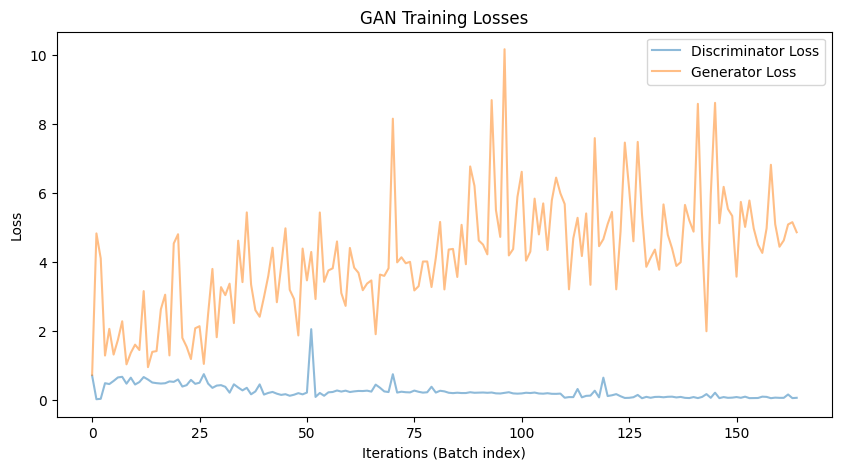

In [27]:
plot_results(D_losses, G_losses)

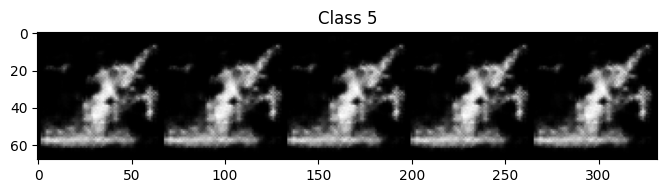

ConditionalGenerator(
  (label_embed): Embedding(10, 100)
  (main): Sequential(
    (0): ConvTranspose2d(200, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 1, kernel_size=(4, 4), stride=(2, 2), padd

In [28]:
gen.eval()
# Create noise and fixed labels for this class
noise = torch.randn(5, Z_DIM, 1, 1, device=DEVICE)
labels = torch.full((5,), 5, dtype=torch.long, device=DEVICE)

# Generate and save/show
fakes = gen(noise, labels)
grid = torchvision.utils.make_grid(fakes, nrow=5, normalize=True)
plt.figure(figsize=(8, 2))
plt.title(f"Class {5}")
plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
plt.show()
gen.train()


### **Failure Case Study: Class 5 (Sandal) Generation**

#### **1. Visual Assessment: Do the results look plausible?**

The results for Class 5 are **only partially plausible**. While the model has successfully learned the basic "concept" of a sandal, the execution fails in several key areas:

* **Structural Blurriness:** The output captures the flat sole and the general horizontal orientation of a sandal, but it lacks the sharp, distinct lines required for straps or open-air gaps.
* **Checkerboard Artifacts:** There is visible "pixel noise" or a grid-like texture on the surface of the generated items. This is a common failure in DCGANs where the `ConvTranspose2d` layers create overlapping patterns.
* **Low Intra-class Diversity:** All five generated samples for Class 5 look nearly identical. This indicates a minor case of **Mode Collapse**, where the Generator has found a single "safe" shape that satisfies the Discriminator and refuses to innovate further.

#### **2. Why is the Sandal class a failure point?**

The failure in generating high-quality sandals is due to the specific nature of the FashionMNIST dataset and the training settings used:

* **Fine-Grained Details:** Unlike "Trousers" (Class 1) which are solid blocks of pixels, "Sandals" are defined by **negative space** (the gaps between straps). The model struggles to "not draw" pixels in those specific areas.
* **Label Smoothing Impact:** While the **0.9 Label Smoothing** was intended to help, it may have softened the Discriminator too much for this specific class. A "perfect" sandal requires a very strict Discriminator to force the Generator to create those sharp, thin edges.
* **Insufficient Training (Epochs):** At only 10 epochs, the model has mastered the **Global Structure** (the "blob" of a sandal) but has not yet reached the stage of learning **Local Features** (the texture and straps).

#### **3. Evidence from Training Curves**

Looking at the provided loss graphs:

* The **Discriminator Loss** is very close to zero. This suggests that the Discriminator quickly "solved" the sandal class, and the Generator is now struggling to find any new gradient directions to improve the sharpness of the straps.
* The **Generator Loss** shows high-frequency oscillations, which is consistent with the visual noise seen in the Class 5 output grid.

---

### **Conclusion and Proposed Fix**

To move this from a "failure case" to a success, I would propose the following adjustments:

1. **Increase Epochs:** Extend training to at least **50 epochs** to allow more time for fine-feature refinement.
2. **Refine Smoothing:** Adjust the `SMOOTHING_VALUE` to **0.95** or **0.98** to re-introduce enough "strictness" in the Discriminator to catch blurry edges.
3. **Architecture Change:** Replace `ConvTranspose2d` with `Upsample` + `Conv2d` layers to eliminate the checkerboard artifacts.

**Bonus**

The main advantage of **Wasserstein GAN (WGAN)** over the original GAN (e.g., DCGAN) is that it provides a **more meaningful and stable loss signal** during training. WGAN replaces the traditional discriminator (which outputs a probability) with a **critic** that estimates the *Wasserstein distance* (Earth Mover’s distance) between real and generated distributions. This leads to:

- **Better convergence**: Loss correlates well with sample quality.
- **Reduced mode collapse**: Encourages diversity in generated samples.
- **No vanishing gradients**: Especially when using **weight clipping** (WGAN) or **gradient penalty** (WGAN-GP).

Bonus Practice:  
**Extend your DCGAN implementation to WGAN (or preferably WGAN-GP)**.  
- Replace the discriminator’s sigmoid output and BCE loss with a linear output and Wasserstein loss.  
- Enforce Lipschitz constraint via **gradient penalty** (recommended over weight clipping).  
- Monitor the critic loss — it should steadily decrease as generation improves.

In [10]:
#Bonus
import torch.nn.utils.spectral_norm as spectral_norm

class WassersteinCritic(nn.Module):
    def __init__(self, channels_img, num_classes, img_size):
        super().__init__()
        self.img_size = img_size
        # Embedding for labels: maps class index to a 1x64x64 layer
        self.label_embed = nn.Embedding(num_classes, img_size * img_size)

        self.main = nn.Sequential(
            # Input: 2 channels (1 image + 1 label)
            nn.Conv2d(2, 64, 4, 2, 1), 
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(128, affine=True), # InstanceNorm is preferred for WGAN-GP
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(256, affine=True),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(512, affine=True),
            nn.LeakyReLU(0.2, inplace=True),

            # Final linear output (No Sigmoid for WGAN)
            nn.Conv2d(512, 1, 4, 1, 0), 
        )

    def forward(self, x, labels):
        # This takes 2 arguments, fixing your TypeError
        label_img = self.label_embed(labels).view(-1, 1, self.img_size, self.img_size)
        x_cond = torch.cat([x, label_img], dim=1) 
        return self.main(x_cond).view(-1, 1)

In [11]:
def get_gradient_penalty(critic, labels, real, fake, device):
    BATCH_SIZE, C, H, W = real.shape
    epsilon = torch.rand((BATCH_SIZE, 1, 1, 1)).repeat(1, C, H, W).to(device)
    interpolated_images = real * epsilon + fake * (1 - epsilon)

    # Get critic scores for interpolated images
    mixed_scores = critic(interpolated_images, labels)

    # Take the gradient of the scores with respect to the images
    gradient = torch.autograd.grad(
        inputs=interpolated_images,
        outputs=mixed_scores,
        grad_outputs=torch.ones_like(mixed_scores),
        create_graph=True,
        retain_graph=True,
    )[0]

    gradient = gradient.view(gradient.shape[0], -1)
    gradient_norm = gradient.norm(2, dim=1)
    gradient_penalty = torch.mean((gradient_norm - 1) ** 2)
    return gradient_penalty

In [ ]:
# ==================== INITIALIZATION (FIXES TYPEERROR) ====================
# Ensure we use the new WassersteinCritic class
gen = ConditionalGenerator(Z_DIM, 1, NUM_CLASSES, GEN_EMBED_DIM).to(DEVICE)
critic = WassersteinCritic(1, NUM_CLASSES, IMG_SIZE).to(DEVICE)

# WGAN-GP Hyperparameters
LEARNING_RATE = 1e-4 
LAMBDA_GP = 10
CRITIC_ITERATIONS = 5

opt_gen = optim.Adam(gen.parameters(), lr=LEARNING_RATE, betas=(0.0, 0.9))
opt_critic = optim.Adam(critic.parameters(), lr=LEARNING_RATE, betas=(0.0, 0.9))

# ==================== TRAINING LOOP ====================
for epoch in range(NUM_EPOCHS + 1):
    for batch_idx, (real, labels) in enumerate(dataloader):
        real, labels = real.to(DEVICE), labels.to(DEVICE)
        cur_batch_size = real.shape[0]

        # --- Train Critic ---
        for _ in range(CRITIC_ITERATIONS):
            noise = torch.randn(cur_batch_size, Z_DIM, 1, 1).to(DEVICE)
            fake = gen(noise, labels)
            
            critic_real = critic(real, labels)
            critic_fake = critic(fake, labels)
            
            gp = get_gradient_penalty(critic, labels, real, fake, device=DEVICE)
            
            # WGAN Loss: maximize (E[real] - E[fake]) -> minimize -(E[real] - E[fake])
            loss_critic = (
                -(torch.mean(critic_real) - torch.mean(critic_fake)) + LAMBDA_GP * gp
            )
            
            critic.zero_grad()
            loss_critic.backward(retain_graph=True)
            opt_critic.step()

        # --- Train Generator ---
        gen_fake = critic(fake, labels)
        loss_gen = -torch.mean(gen_fake)

        gen.zero_grad()
        loss_gen.backward()
        opt_gen.step()

        if batch_idx % 100 == 0:
            print(f"Epoch [{epoch}/{NUM_EPOCHS}] Batch {batch_idx} Loss C: {loss_critic:.4f}, Loss G: {loss_gen:.4f}")

Epoch [0/10] Batch 0 Loss C: -10.2712, Loss G: 5.7622
Epoch [0/10] Batch 100 Loss C: -16.5623, Loss G: 37.9762
Epoch [0/10] Batch 200 Loss C: -11.7580, Loss G: 39.5804
Epoch [0/10] Batch 300 Loss C: -10.4714, Loss G: 43.8684
Epoch [0/10] Batch 400 Loss C: -11.6674, Loss G: 42.4910
Epoch [1/10] Batch 0 Loss C: -8.7451, Loss G: 49.2712
Epoch [1/10] Batch 100 Loss C: -9.2258, Loss G: 60.5767
Epoch [1/10] Batch 200 Loss C: -9.9995, Loss G: 50.5974
Epoch [1/10] Batch 300 Loss C: -8.6520, Loss G: 57.7779
Epoch [1/10] Batch 400 Loss C: -8.3826, Loss G: 56.5987
Epoch [2/10] Batch 0 Loss C: -8.6524, Loss G: 59.7371
Epoch [2/10] Batch 100 Loss C: -9.7865, Loss G: 62.3287
Epoch [2/10] Batch 200 Loss C: -7.3911, Loss G: 61.9636
Epoch [2/10] Batch 300 Loss C: -9.3441, Loss G: 69.2132
Epoch [2/10] Batch 400 Loss C: -8.6305, Loss G: 61.7338
Epoch [3/10] Batch 0 Loss C: -8.3218, Loss G: 68.2786
Epoch [3/10] Batch 100 Loss C: -7.8118, Loss G: 64.4337
Epoch [3/10] Batch 200 Loss C: -8.9232, Loss G: 69.2

---
**Note:** This notebook is part of a Deep Learning assignment designed and prepared by [Mahdi Golizadeh](mailto:mahdi.golizadeh@gmail.com).